Steps:
1. Import packages needed
2. Input data / Create Function for Lemmatizing Data
3. Creatures
<br>&emsp;3a. Prep data (includes lemmatize, train test split, normalize)
<br>&emsp;3b. Create model with Hyperparameter analysis
<br>&emsp;3c. Acquire parameters / Evaluate model
<br>&emsp;3d. Visualizations (GridSearch Heatmap, Scatterplot with best Gridsearch)
4. Planes Walkers
<br>&emsp;4a. Prep data (includes lemmatize, train test split, normalize)
<br>&emsp;4b. Create model with Hyperparameter analysis
<br>&emsp;4c. Acquire parameters / Evaluate model
<br>&emsp;4d. Visualizations (GridSearch Heatmap, Scatterplot with best Gridsearch)
5. Non-Creatures (Enchantments, Artifacts, and Instants)
<br>&emsp;5a. Prep data (includes lemmatize, train test split, normalize)
<br>&emsp;5b. Create model with Hyperparameter analysis
<br>&emsp;5c. Acquire parameters / Evaluate model
<br>&emsp;5d. Visualizations (GridSearch Heatmap, Scatterplot with best Gridsearch)
<br>&emsp;5e. Failure Analysis (SHAP values and visualizations)

# 1. Import Packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
np.set_printoptions(precision=5)
random_state = 42
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MultiLabelBinarizer

# packages for visualizations
import altair as alt
import math
alt.data_transformers.enable("vegafusion")
alt.renderers.enable("jupyter")

#packages for lemmatization
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer

# word libraries for lemmatization
nltk.download('wordnet')
nltk.download('punkt')

# for failure analysis
import shap
shap.initjs()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jaymj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jaymj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# 2. Input Data / Create Function for Lemmatizing Data

In [3]:
#import data from the MTGJSON data set
mtgjson_data_df = pd.read_csv('data/finalCards.csv')
mtgjson_data_df['text'] = mtgjson_data_df['text'].astype('string').fillna('')

data_before = [
    'isAlternative',
    'isGameChanger', 
    'isPromo',
    'isReprint', 
    'isReserved',
    'isHuman', 
    'isElemental',
    'isDragon', 
    'isSpirit', 
    'isAngel', 
    'isElf', 
    'isVampire', 
    'isZombie',
    'isBeast', 
    'isWizard', 
    'isSoldier', 
    'isKnight', 
    'isCleric', 
    'isWarrior',
    'isRogue', 
    'isShaman', 
    'isDruid', 
    'isCreature', 
    'isPlaneswalker', 
    'isMTGO', 
    'isFlying',
    'isLegal',
    'isBanned']

#update binary columns to show 0 and 1 for regression

for col in data_before:
    mtgjson_data_df[col] = mtgjson_data_df[col].map({True: 1, False: 0})

ridge_lasso_data_df = mtgjson_data_df[[
    'uuid', 
    'cardName', 
    'availability', 
    'colorIdentity', 
    'edhrecRank', 
    'edhrecSaltiness', 
    'finishes', 
    'isAlternative', 
    'isGameChanger',
    'isPromo',
    'isReprint',
    'isReserved',
    'manaValue',
    'cardNumber',
    'power',
    'rarity',
    'setCode',
    'subtypes',
    'text',
    'toughness',
    'types',
    'price',
    'commander',
    'setName',
    'releaseDate',
    'scryfallId',
    'isHuman', 
    'isElemental',
    'isDragon', 
    'isSpirit', 
    'isAngel', 
    'isElf',
    'isVampire', 
    'isZombie',
    'isBeast', 
    'isWizard',
    'isEldrazi', 
    'isSoldier', 
    'isKnight', 
    'isCleric', 
    'isWarrior',
    'isRogue', 
    'isShaman', 
    'isDruid', 
    'isCreature',
    'isPlaneswalker',
    'isMTGO', 
    'isFlying',
    'isLegal',
    'isBanned'
    ]]


#Create a few more binary columns for finishes, color identity and rarity of cards
ridge_lasso_data_df['finishes'] = ridge_lasso_data_df['finishes'].str.split(', ')
mlb = MultiLabelBinarizer()
encoded_finishes = mlb.fit_transform(ridge_lasso_data_df['finishes'])
finishes_df = pd.DataFrame(encoded_finishes, columns="finishes:_"+mlb.classes_)

ridge_lasso_data_df['colorIdentity'] = ridge_lasso_data_df['colorIdentity'].str.split(', ')
ci_mlb = MultiLabelBinarizer()
encoded_colorid = ci_mlb.fit_transform(ridge_lasso_data_df['colorIdentity'])
colorid_df = pd.DataFrame(encoded_colorid, columns="colorid:_"+ci_mlb.classes_)

rarity_df = pd.get_dummies(ridge_lasso_data_df['rarity'], prefix="rarity:")

ridge_lasso_data_df = pd.concat([ridge_lasso_data_df,rarity_df,finishes_df,colorid_df], axis=1)
ridge_lasso_data_df = ridge_lasso_data_df.drop(['rarity','finishes','colorIdentity'], axis=1)

#clean data for analysis
column_uniqueval_df = {}
na_column_uniqueval = {}
for column in ridge_lasso_data_df.columns:
    if "id" in column or "Name" in column or "price" in column or 'Id' in column: 
        ridge_lasso_data_df.dropna(subset=[column])
    elif "is" in column or "rarity" in column or "power" in column or "toughness" in column: 
        ridge_lasso_data_df[column] = ridge_lasso_data_df[column].fillna(0)
    else:
        if pd.isna(ridge_lasso_data_df[column].unique().tolist()).any():
            na_column_uniqueval.update({column : ridge_lasso_data_df[column].unique()})
        else:
            column_uniqueval_df.update({column : ridge_lasso_data_df[column].unique()})

#Total number of cards before and after final removal of rows with NAN values
print(f'Quantity of cards PRIOR to dropping NA values: {len(ridge_lasso_data_df)}')
ridge_lasso_data_df = ridge_lasso_data_df.dropna()
print(f'Quantity of cards AFTER to dropping NA values: {len(ridge_lasso_data_df)}')

C:\Users\jaymj\AppData\Local\Temp\ipykernel_5752\3715038383.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ridge_lasso_data_df['finishes'] = ridge_lasso_data_df['finishes'].str.split(', ')
C:\Users\jaymj\AppData\Local\Temp\ipykernel_5752\3715038383.py:100: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ridge_lasso_data_df['colorIdentity'] = ridge_lasso_data_df['colorIdentity'].str.split(', ')


Quantity of cards PRIOR to dropping NA values: 94123
Quantity of cards AFTER to dropping NA values: 46113


In [4]:
# combine duplicate rows (card variants with the same feature values) and use the average price as the target price
# card variants with unique attributes will be kept as separate rows
def aggregateDuplicates(df):
    #input: df - DataFrame with duplicate rows includes 'price' column
    #return: df - DataFrame aggregated with average prices
    group_by_cols = [col for col in df.columns if col != 'price']
    return df.groupby(group_by_cols)['price'].mean().reset_index()

### Add Lemmatization Step for cleaning text

In [5]:
#Lemmatize sentences to tokenize and commonize root words
def lemmatize_sentence(sentence):
    #input: sentence - string that includes English words
    #return: string with updated sentence of lemmatized words
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(sentence)
    lemmatized_tokens = [lemmatizer.lemmatize(token)+' ' for token in tokens]
    return ''.join(lemmatized_tokens)

# 3. Creature Analysis

## 3a. Prep data (includes lemmatize, train test split, normalize)

#### Extract Creature Data and Lemmatize the ability text

In [6]:
#extract creature data only and average prices for duplicate cards with exact features
creatures_df = ridge_lasso_data_df[ridge_lasso_data_df['isCreature'] == 1].copy()
creatures_df = aggregateDuplicates(creatures_df)
creatures_df.head(5)

,uuid,cardName,availability,edhrecRank,edhrecSaltiness,isAlternative,isGameChanger,isPromo,isReprint,isReserved,...,finishes:_foil,finishes:_nonfoil,finishes:_signed,colorid:_B,colorid:_Colorless,colorid:_G,colorid:_R,colorid:_U,colorid:_W,price
0,00010d56-fe38-5e35-8aed-518019aa36a5,Sphinx of the Final Word,paper,10186.0,0.14,0,0,1,1,0,...,1,0,0,0,0,0,0,1,0,7.910000
1,0001e0d0-2dcd-5640-aadc-a84765cf5fc9,Goblin King,paper,3454.0,0.34,0,0,0,1,0,...,0,1,0,0,0,0,1,0,0,4.715000
2,0003d249-25d9-5223-af1e-1130f09622a7,Deadshot Minotaur,"mtgo, paper",25150.0,0.20,0,0,0,0,0,...,1,1,0,0,0,1,1,0,0,0.234444
3,0005283f-d113-5937-ba52-a30570bfb334,Grave Titan,"mtgo, paper",1366.0,0.21,0,0,0,1,0,...,0,1,0,1,0,0,0,0,0,0.810000
4,00054115-b2b6-5e22-a694-76fc8639eeb2,Merfolk Looter,paper,4221.0,0.24,0,0,0,1,0,...,0,1,1,0,0,0,0,1,0,0.510000


In [7]:
#lemmatize creature ability text
creatures_df['text_lemmatized'] = creatures_df['text'].apply(lemmatize_sentence)

#### Vectorize text using TF-IDF and Count Quantities

In [8]:
#Acquire counts for each word (not including stop words)
creature_min_ngram = 1
creature_max_ngram = 3
stop_words = 'english'
vectorizer = 15

#TF IDF dataframe
creature_tfidf_vectorizer = TfidfVectorizer(
    max_features=vectorizer,
    stop_words=stop_words,
    ngram_range=(creature_min_ngram,creature_max_ngram)
    )
creature_tfidf_model = creature_tfidf_vectorizer.fit_transform(creatures_df['text_lemmatized'])
creature_tfidf_ability_text = creature_tfidf_vectorizer.get_feature_names_out()
creature_tfidf_stop_words_vect = creature_tfidf_vectorizer.get_stop_words()
creature_tfidf_columns_text = ["contains_tfidf: "+ item for item in creature_tfidf_ability_text]
creature_tfidf_words_df = pd.DataFrame(
    creature_tfidf_model.toarray(),
    columns=creature_tfidf_columns_text)
creature_final_df = creatures_df.join(creature_tfidf_words_df).fillna(0)

#Count Vectorizer dataframe
creature_count_vectorizer = CountVectorizer(
    max_features=vectorizer,
    stop_words=stop_words,
    ngram_range=(creature_min_ngram,creature_max_ngram)
    )
creature_count_model = creature_count_vectorizer.fit_transform(creatures_df['text_lemmatized'])
creature_count_ability_text = creature_count_vectorizer.get_feature_names_out()
creature_count_stop_words_vect = creature_count_vectorizer.get_stop_words()
creature_count_columns_text = ["contains_count: "+ item for item in creature_count_ability_text]
creature_count_words_df = pd.DataFrame(
    creature_count_model.toarray(),
    columns=creature_count_columns_text)
creature_final_df = creature_final_df.join(creature_count_words_df).fillna(0)

#### Train Test Split MTGJSON Data

In [9]:
# Identify Creature features to analyze (X) and price (Y)
creature_X_columns = [
        'power', 
        'toughness', 
        'price', 
        'edhrecRank',
        'edhrecSaltiness', 
        'manaValue',
        'isReprint',
        'isAlternative',
        'isGameChanger',
        'isPromo',
        'isReserved',
        'isHuman', 
        'isElemental',
        'isDragon', 
        'isSpirit', 
        'isAngel', 
        'isElf',
        'isVampire', 
        'isZombie',
        'isBeast', 
        'isWizard',
        'isEldrazi',
        'isSoldier', 
        'isKnight', 
        'isCleric', 
        'isWarrior',
        'isRogue', 
        'isShaman', 
        'isDruid', 
        'isMTGO', 
        'isFlying',
        'isLegal',
        'isBanned',
        'rarity:_common',
        'rarity:_mythic',
        'rarity:_rare',
        'rarity:_special',
        'rarity:_uncommon',
        'finishes:_etched',
        'finishes:_foil',
        'finishes:_nonfoil',
        'finishes:_signed',
        'colorid:_B',
        'colorid:_Colorless',
        'colorid:_G',
        'colorid:_R',
        'colorid:_U',
        'colorid:_W'
        ] + creature_tfidf_columns_text + creature_count_columns_text
creature_y_column = "price"
creature_X_columns.remove(creature_y_column)

creature_X = creature_final_df[creature_X_columns]
creature_y = creature_final_df[creature_y_column]

#Split Data
creature_X_train_raw, creature_X_test_raw, creature_y_train_raw, creature_y_test_raw = train_test_split(
    creature_X,
    creature_y,
    random_state=random_state
    )

#Normalize data for non binary columns
creature_scaled_columns = [
        'power',
        'toughness',
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue']
creature_X_train_norm= creature_X_train_raw.copy()
creature_X_test_norm = creature_X_test_raw.copy()
creature_train_features = creature_X_train_norm[creature_scaled_columns]
creature_test_features = creature_X_test_norm[creature_scaled_columns]

creature_scaler = StandardScaler().fit(creature_train_features.values)
creature_train_features = creature_scaler.transform(creature_train_features.values)
creature_test_features = creature_scaler.transform(creature_test_features.values)

creature_X_train_norm[creature_scaled_columns] = creature_train_features
creature_X_test_norm[creature_scaled_columns] = creature_test_features

## 3b. Create Model with Hyperparameter Tuning

### Parameters to tune

In [10]:
#Parameters with and GridSearch for both Lasso and Ridge Regression
parameters = {
    'alpha' : [1, 25, 50, 100]
    }

### Ridge Model

In [11]:
#create a ridge model that also provides graph
def ridge_model_with_graph(X_train, y_train, card_type, num_alphas = 200):

    alphas = np.logspace(-10.0, 10.0, num_alphas)
    coefs = []
    score = []
    best_model_score = -1.0
    best_model = None

    # acquire scores and coefficients for each value of lambda used for regularization
    for a in alphas:
        ridge = Ridge(alpha=a, fit_intercept=False)
        scores = cross_validate(
            ridge,
            X_train,
            y_train,
            cv=5,
            return_estimator=True, 
            return_train_score=True,
            scoring=[
                'r2',
                'neg_mean_squared_error',
                'neg_mean_absolute_error'
                ]
            )
        current_score = scores['test_r2'].mean()
        current_score_std_dev = scores['test_r2'].std()
        current_mse = scores['test_neg_mean_squared_error'].mean()
        current_mse_std_dev = scores['test_neg_mean_squared_error'].std()
        current_mae = scores['test_neg_mean_absolute_error'].mean()
        current_mae_std_dev = scores['test_neg_mean_absolute_error'].std()

        coef_model_splits = []
        for model in scores['estimator']:
            coef_model_splits.append(model.coef_)
        
        current_coef_df=pd.DataFrame(coef_model_splits)
        coefficients_avg = current_coef_df.mean().to_list()
            
        
        current_estimator = scores['estimator']
        score.append({'Model_Reg_Lambda': a,
                      'Model_Score': current_score,
                      'Model_Score_std_dev': current_score_std_dev,
                      'MSE': current_mse,
                      'MSE_std_dev': current_mse_std_dev,
                      'MAE': current_mae,
                      'MAE_std_dev': current_mae_std_dev})
        coefs.append({'Coefficients':coefficients_avg,
                      'Features': X_train.columns.tolist(),
                     'Model_Reg_Lambda':a,
                      'Model_Score': current_score}
                      )
        
        #acquire the best model out of all alphas to return
        if current_score > best_model_score:
            best_model = current_estimator
            best_model_score = current_score

    #Dataframe to use for coefficient plot
    coefficients_data_df = pd.DataFrame(
        coefs,
        columns=[
            'Coefficients',
            'Features',
            'Model_Reg_Lambda',
            'Model_Score'
        ]
        ).explode(['Coefficients','Features'])
    

    coefficients_data_df.sort_values(
            by=['Model_Score','Model_Reg_Lambda', 'Coefficients'],
            ascending = [False, True, False],
            inplace=True
        )
    
    score_data_df = pd.DataFrame(
        score,
        columns=[
            'Model_Reg_Lambda',
            'Model_Score',
            'Model_Score_std_dev',
            'MSE',
            'MSE_std_dev',
            'MAE',
            'MAE_std_dev'
            ]
        )
    
    score_data_df.sort_values(
            by='Model_Score',
            inplace=True,
            ascending=False
            )
    
    top_20_scores = score_data_df['Model_Score'].tolist()[:21]
    features_score = pd.pivot_table(
        coefficients_data_df[coefficients_data_df['Model_Score'].isin(top_20_scores)],
        values= 'Coefficients',
        index='Features',
        aggfunc= 'mean').reset_index()
    features_score['Absolute_Coeff'] = np.abs(features_score['Coefficients'])
    features_top_20_score = features_score.sort_values(by='Absolute_Coeff', ascending=False)[:21]

    #Extract only top 20 features to show in coefficient plot
    top_20_feature_data_df = coefficients_data_df[
        coefficients_data_df['Features'].isin(features_top_20_score['Features'])
        ]

    #Use altair to plot coefficients
    line_plot = alt.Chart(top_20_feature_data_df).mark_line().encode(
        x=alt.X(
            "Model_Reg_Lambda:Q",
            title = "Model Regularization level (Lambda)",
            scale= alt.Scale(type = 'log')
            ),
        y=alt.Y(
            "Coefficients:Q",
            title = "Coefficient Weights",
            scale= alt.Scale(
                domain=[
                    math.ceil(np.abs(coefficients_data_df['Coefficients']).max()*1.2),
                    -1*math.ceil(np.abs(coefficients_data_df['Coefficients']).max()*1.2)
                ]
            )
        ),
        color=alt.Color(
            "Features:N",
            legend=alt.Legend(title="Features", titleFontSize=18, labelFontSize=16)
        ),
        tooltip=['Features:N']
    )

    #mark best score on graph to identify approximate values for each coefficient
    alpha_lines = alt.Chart(
        score_data_df.head(1)
        ).mark_rule(
            color="#999999",
            strokeWidth=2,
            strokeDash=[6,3],
        ).encode(
            x=alt.X('Model_Reg_Lambda:Q')
    )

    annotation = alpha_lines.mark_text(
        align='left',
        baseline='top',
        dy=375,
        dx=10,
        color="#999999",
    ).encode(
        text=alt.Text('Model_Reg_Lambda:Q', format='.2f'
                       ),
    )

    chart = alt.layer(line_plot, annotation, alpha_lines
        ).properties(
            width=1000,
            height=800,
            title=alt.Title(
                text=f"Coefficient Path Plot of {card_type} Cards",
                fontSize=28,
                anchor="middle"),
        ).configure_axis(
            labelFontSize=14,
            titleFontSize=22,
            gridOpacity=0.3,
            title=f"Coefficient Path Plot for Top 20 {card_type} Card Elements",
        ).configure_view(
            strokeWidth=0
        ).configure_legend(
            orient="right", 
            labelFontSize=12
        ).configure_text(
            fontSize=16
        )
    
    
    return best_model, coefficients_data_df, score_data_df, chart

In [12]:
#Create Ridge Regression Model
creature_ridge_clf = Ridge()

#Fit model with TF-IDF
creature_X_train_norm_tfidf = creature_X_train_norm.copy().drop(columns=creature_count_columns_text)
creature_X_test_norm_tfidf = creature_X_test_norm.copy().drop(columns=creature_count_columns_text)
creature_ridge_clf_hyp = GridSearchCV(estimator=creature_ridge_clf, param_grid=parameters, cv=5)
creature_ridge_clf_hyp_tfidf = creature_ridge_clf_hyp.fit(
    creature_X_train_norm_tfidf,
    creature_y_train_raw)
creature_ridge_tfidf_score = creature_ridge_clf_hyp_tfidf.score(
    creature_X_test_norm_tfidf,
    creature_y_test_raw)
print("Ridge TF-IDF Score: ",creature_ridge_tfidf_score)

#Fit model with Count Quantities
creature_X_train_norm_count = creature_X_train_norm.copy().drop(columns=creature_tfidf_columns_text)
creature_X_test_norm_count =creature_X_test_norm.copy().drop(columns=creature_tfidf_columns_text)
creature_ridge_clf_hyp = GridSearchCV(estimator=creature_ridge_clf, param_grid=parameters, cv=5)
creature_ridge_clf_hyp_count = creature_ridge_clf_hyp.fit(
    creature_X_train_norm_count,
    creature_y_train_raw)
creature_ridge_count_score = creature_ridge_clf_hyp_count.score(
    creature_X_test_norm_count,
    creature_y_test_raw)
print("Ridge Count Score: ",creature_ridge_count_score)


#Identify best model
if creature_ridge_tfidf_score > creature_ridge_count_score:
    creature_X_train_norm_ridge = creature_X_train_norm.copy().drop(
        columns=creature_count_columns_text)
    creature_X_test_norm_ridge = creature_X_test_norm.copy().drop(
        columns=creature_count_columns_text)
    if creature_X_train_norm_ridge.columns.str.contains("contains_count: ").any():
        print("CHECK COLUMNS")
        print(creature_X_train_norm_ridge.columns[
            creature_X_train_norm_ridge.columns.str.contains("contains_count: ")].tolist())
    else:
        print("COLUMNS ARE GOOD")
        print("USE TDF-IDF SCORE FOR RIDGE MODEL")
else:
    creature_X_train_norm_ridge = creature_X_train_norm.copy().drop(
        columns=creature_tfidf_columns_text)
    creature_X_test_norm_ridge = creature_X_test_norm.copy().drop(
        columns=creature_tfidf_columns_text)
    if creature_X_train_norm_ridge.columns.str.contains("contains_tfidf: ", case=False).any():
        print("CHECK COLUMNS")
        print(creature_X_train_norm_ridge.columns[
            creature_X_train_norm_ridge.columns.str.contains("contains_tfidf: ")].tolist())
    else:
        print("COLUMNS ARE GOOD")
        print("USE COUNT QUANTITIES FOR LASSO MODEL")

creature_ridge_clf_hyp, creat_r_coeffs_df, creat_r_score_df, creat_r_line_plot = ridge_model_with_graph(
    creature_X_train_norm_ridge, 
    creature_y_train_raw, 
    "Creature",
    num_alphas=2000)

creature_ridge_clf_hyp = creature_ridge_clf_hyp[-1]

Ridge TF-IDF Score:  0.0045868089075927765
Ridge Count Score:  0.004301479135805586
COLUMNS ARE GOOD
USE TDF-IDF SCORE FOR RIDGE MODEL


## 3c. Acquire Parameters / Evaluate Metrics

In [13]:
#Gather Evaluation metrics for Ridge model from function
creature_ridge_y_predict = creature_ridge_clf_hyp.predict(creature_X_test_norm_ridge)
creature_ridge_mse = creat_r_score_df.iloc[0,3]
creature_ridge_mse_std_dev = creat_r_score_df.iloc[0,4]
creature_ridge_mae = creat_r_score_df.iloc[0,5]
creature_ridge_mae_std_dev = creat_r_score_df.iloc[0,6]
creature_ridge_best_score = creat_r_score_df.iloc[0,1]
creature_ridge_std_dev = creat_r_score_df.iloc[0,2]
creature_ridge_alpha_value = creat_r_score_df.iloc[0,0]

print("RIDGE MODEL for CREATURES")
print(f"Best Regulation value (Lambda/Alpha Score): {creature_ridge_alpha_value}")
print(f"Best R-Square Score of Test Data (Mean[STD_DEV]): {creature_ridge_best_score} [{creature_ridge_std_dev}]")
print(f"Mean Square error (Mean[STD_DEV]): {creature_ridge_mse*-1} [{creature_ridge_mse_std_dev}]")
print(f"Mean Absolute error (Mean[STD_DEV]): {creature_ridge_mae*-1}  [{creature_ridge_mae_std_dev}]")
print("----------------------------------------")

RIDGE MODEL for CREATURES
Best Regulation value (Lambda/Alpha Score): 3.056628240680404
Best R-Square Score of Test Data (Mean[STD_DEV]): 0.027727731895176945 [0.008749904285236174]
Mean Square error (Mean[STD_DEV]): 6120.514392598062 [2910.857917905014]
Mean Absolute error (Mean[STD_DEV]): 13.543148806549828  [0.7928308226894267]
----------------------------------------


In [14]:
#Evaluate feature_importance for ridge Model
creature_ridge_feature_importance = pd.DataFrame(
    creat_r_coeffs_df[creat_r_coeffs_df['Model_Score'].isin([creature_ridge_best_score])])

creature_ridge_feature_importance['Abs_Val_Coefficients'] = abs(creature_ridge_feature_importance['Coefficients'])
creature_ridge_feature_importance.sort_values('Abs_Val_Coefficients', ascending=False, inplace=True)
print("RIDGE MODEL")
creature_ridge_feature_importance.head(25)

RIDGE MODEL


,Coefficients,Features,Model_Reg_Lambda,Model_Score,Abs_Val_Coefficients
1048,74.339062,isReserved,3.056628,0.027728,74.339062
1048,66.503503,rarity:_mythic,3.056628,0.027728,66.503503
1048,64.389938,rarity:_special,3.056628,0.027728,64.389938
1048,57.306928,rarity:_rare,3.056628,0.027728,57.306928
1048,52.993178,rarity:_uncommon,3.056628,0.027728,52.993178
1048,50.968726,rarity:_common,3.056628,0.027728,50.968726
1048,-37.247985,finishes:_signed,3.056628,0.027728,37.247985
1048,-18.797602,finishes:_etched,3.056628,0.027728,18.797602
1048,-17.799789,isLegal,3.056628,0.027728,17.799789
1048,-14.719063,isPromo,3.056628,0.027728,14.719063


## 3d. Visualizations

#### Residual Plot Function

In [15]:
#Input predicted and actual values to understand plot residuals
def residual_plot(y_raw, y_pred, title="Residual Plot"):

    residuals = y_raw - y_pred
    std_residual = np.std(residuals)

    residual_data_df = pd.DataFrame(
        {'Residuals': residuals,
        'Fitted_Values' : y_pred,
            }
    )

    residual_data_df = residual_data_df[(np.abs(residual_data_df['Residuals']) < 3 * std_residual)]

    residual_data_df['isOutlier'] = np.where(
        np.abs(residual_data_df['Residuals']) > 2 * std_residual,
        "Outlier", 
        "Normal")


    scatter_plot = alt.Chart(residual_data_df).mark_point().encode(
        x=alt.X("Fitted_Values:Q", title = "Predicted Price Values"),
        y=alt.Y(
            "Residuals:Q",
            title = "Residual Error between Predicted and Actual Price Value",
            scale=alt.Scale(domain=[-3*std_residual, 3*std_residual])
        ),
        color=alt.Color(
            "isOutlier:N",
            scale=alt.Scale(domain=["Normal", "Outlier"], range=["#009E73", "#D55E00"]),
            legend=alt.Legend(title="Normality", titleFontSize=18, labelFontSize=16)
        ),
        tooltip=['Fitted_Values:Q', 'Residuals:Q']
    )

    zero_line = alt.Chart(pd.DataFrame({'y':[0]})).mark_rule(
        color="#333333",
        strokeWidth=2,
        strokeDash=[6,3],
        ).encode(
        y=alt.Y('y:Q')
    )

    std_lines = alt.Chart(
        pd.DataFrame(
            {'y':[2*std_residual,-2*std_residual],
                'labels': ['2 std deviation above mean',
                        '-2*std deviation below mean'
                    ]        
                }
            )
        ).mark_rule(
        color="#999999",
        strokeWidth=2,
        strokeDash=[6,3],
        ).encode(
        y=alt.Y('y:Q')
    )

    chart = (
        alt.layer(zero_line, std_lines, scatter_plot)
        .properties(
            width=800,
            height=800,
            title=alt.Title(text=title, fontSize=28, anchor="middle"),
        )
        .configure_axis(labelFontSize=14, titleFontSize=22, gridOpacity=0.3)
        .configure_view(strokeWidth=0)
        .configure_legend(orient="right")
    )

    return chart

In [16]:
#plot residual plot based on results
creature_chart = residual_plot(
    creature_y_test_raw, 
    creature_ridge_y_predict, 
    "Residual Plot for MTG Creature Cards")
creature_chart.show()

In [17]:
#function to plot actual versus predicted values on plot
def pred_vs_actual(y_test, y_pred, graphtype):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
    plt.plot(
        [min(y_test), max(y_test)],
        [min(y_test), max(y_test)],
        color='red',
        linewidth=2,
        label='Ideal fit'
        )
    plt.title(graphtype + ' Ridge Regression: Predicted vs Actual Price (USD)')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.legend()
    return plt

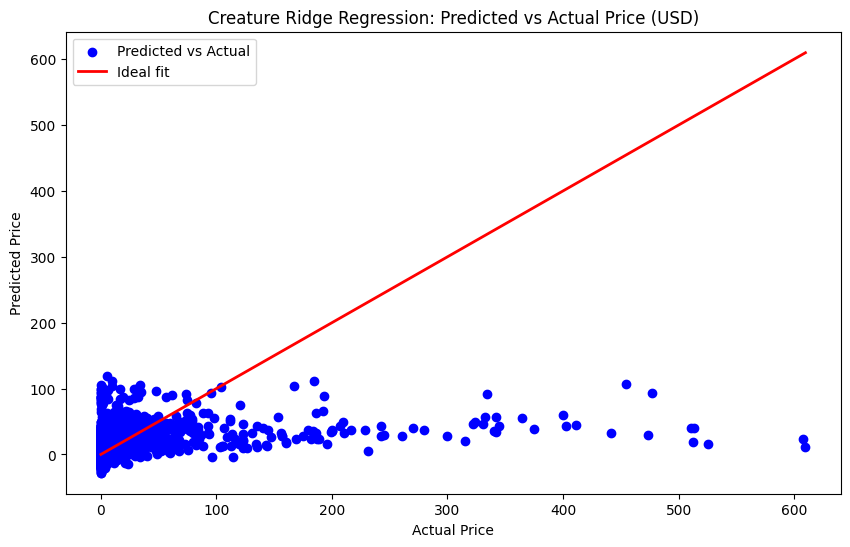

In [18]:
#plot actual versus predicted values on plot
y_values_dict = {
    'creature_y_test_raw': creature_y_test_raw,
    'creature_ridge_y_predict': creature_ridge_y_predict}
y_values = pd.DataFrame(
    y_values_dict,
    columns=['creature_y_test_raw', 'creature_ridge_y_predict'])
y_values_3std_max = (y_values['creature_y_test_raw'].std()*3)+y_values['creature_y_test_raw'].mean()
y_values_adj = y_values[abs(y_values['creature_y_test_raw'])< y_values_3std_max ]

creat_pred_vs_actual_plt = pred_vs_actual(
    y_values_adj['creature_y_test_raw'],
    y_values_adj['creature_ridge_y_predict'],
    "Creature"
    )
creat_pred_vs_actual_plt.show()

#### Coefficient Path Plot Function

In [19]:
#plot coefficient path plot from regression function
creat_r_line_plot.show()

# 4. Planeswalker Analysis

## 4a. Prep data (includes lemmatize, train test split, normalize)

#### Extract Creature Data and Lemmatize the ability text

In [20]:
#extract planeswalker data only and average prices for duplicate cards with exact features
planeswalk_df = ridge_lasso_data_df[(ridge_lasso_data_df['isPlaneswalker'] == 1)]
planeswalk_df = aggregateDuplicates(planeswalk_df)
planeswalk_df.head(5)

,uuid,cardName,availability,edhrecRank,edhrecSaltiness,isAlternative,isGameChanger,isPromo,isReprint,isReserved,...,finishes:_foil,finishes:_nonfoil,finishes:_signed,colorid:_B,colorid:_Colorless,colorid:_G,colorid:_R,colorid:_U,colorid:_W,price
0,001e28fe-5bc1-57ef-9814-adc1195a297b,"Liliana, the Last Hope",paper,7063.0,0.26,1,0,0,1,0,...,1,0,0,1,0,0,0,0,0,22.3125
1,00396ed6-b91d-5c78-8760-bb22d8f3e9ca,"Tevesh Szat, Doom of Fools","mtgo, paper",3174.0,0.57,0,0,0,0,0,...,1,1,0,1,0,0,0,0,0,8.5025
2,003d9ecd-53bc-55c7-993f-26ec405f71e4,"Gideon, Martial Paragon","mtgo, paper",15747.0,0.37,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1.1640
3,009c0efc-d03f-5a9d-8df9-d0fd2e94b4ca,"Liliana, Waker of the Dead",paper,5185.0,0.79,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,5.4375
4,00be1adb-2ca4-5485-ba27-94f0e96eb2d9,"Minsc & Boo, Timeless Heroes",paper,3343.0,0.54,1,0,1,1,0,...,1,0,0,0,0,1,1,0,0,11.8100


In [21]:
#lemmatize planeswalker ability text
planeswalk_df['text_lemmatized'] = planeswalk_df['text'].apply(lemmatize_sentence)

#### Vectorize text using TF-IDF and Count Quantities

In [22]:
#Acquire counts for each word (not including stop words)
planeswalk_min_ngram = 1
planeswalk_max_ngram = 3
stop_words = 'english'

#TF IDF dataframe
planeswalk_tfidf_vectorizer = TfidfVectorizer(
    max_features=1,
    stop_words=stop_words,
    ngram_range=(planeswalk_min_ngram,planeswalk_max_ngram))
planeswalk_tfidf_model = planeswalk_tfidf_vectorizer.fit_transform(planeswalk_df['text_lemmatized'])
planeswalk_tfidf_ability_text = planeswalk_tfidf_vectorizer.get_feature_names_out()
planeswalk_tfidf_stop_words_vect = planeswalk_tfidf_vectorizer.get_stop_words()
planeswalk_tfidf_columns_text = ["contains_tfidf: "+ item for item in planeswalk_tfidf_ability_text]
planeswalk_tfidf_words_df = pd.DataFrame(
    planeswalk_tfidf_model.toarray(),
    columns=planeswalk_tfidf_columns_text
    )
planeswalk_final_df = planeswalk_df.join(planeswalk_tfidf_words_df).fillna(0)

#Count Vectorizer dataframe
planeswalk_count_vectorizer = CountVectorizer(
    max_features=8,
    stop_words=stop_words,
    ngram_range=(planeswalk_min_ngram,planeswalk_max_ngram)
    )
planeswalk_count_model = planeswalk_count_vectorizer.fit_transform(planeswalk_df['text_lemmatized'])
planeswalk_count_ability_text = planeswalk_count_vectorizer.get_feature_names_out()
planeswalk_count_stop_words_vect = planeswalk_count_vectorizer.get_stop_words()
planeswalk_count_columns_text = ["contains_count: "+ item for item in planeswalk_count_ability_text]
planeswalk_count_words_df = pd.DataFrame(
    planeswalk_count_model.toarray(),
    columns=planeswalk_count_columns_text
    )
planeswalk_final_df = planeswalk_final_df.join(planeswalk_count_words_df).fillna(0)

#### Train Test Split MTGJSON Data

In [23]:
# Identify Planeswalker features to analyze (X) and price (Y)
planeswalk_X_columns = [
        'power', 
        'toughness', 
        'price', 
        'edhrecRank',
        'edhrecSaltiness', 
        'manaValue',
        'isReprint',
        'isAlternative',
        'isGameChanger',
        'isPromo',
        'isReserved',
        'isHuman', 
        'isElemental',
        'isDragon', 
        'isSpirit', 
        'isAngel', 
        'isElf',
        'isVampire', 
        'isZombie',
        'isBeast', 
        'isWizard',
        'isEldrazi',
        'isSoldier', 
        'isKnight', 
        'isCleric', 
        'isWarrior',
        'isRogue', 
        'isShaman', 
        'isDruid', 
        'isCreature', 
        'isMTGO', 
        'isFlying',
        'isLegal',
        'isBanned',
        'rarity:_common',
        'rarity:_mythic',
        'rarity:_rare',
        'rarity:_special',
        'rarity:_uncommon',
        'finishes:_etched',
        'finishes:_foil',
        'finishes:_nonfoil',
        'finishes:_signed',
        'colorid:_B',
        'colorid:_Colorless',
        'colorid:_G',
        'colorid:_R',
        'colorid:_U',
        'colorid:_W'
        ] + planeswalk_tfidf_columns_text + planeswalk_count_columns_text
planeswalk_y_column = "price"
planeswalk_X_columns.remove(planeswalk_y_column)

planeswalk_X = planeswalk_final_df[planeswalk_X_columns]
planeswalk_y = planeswalk_final_df[planeswalk_y_column]

#Split Data
planeswalk_X_train_raw, planeswalk_X_test_raw, planeswalk_y_train_raw, planeswalk_y_test_raw = train_test_split(
    planeswalk_X,
    planeswalk_y,
    random_state=random_state
    )

#Normalize data for non binary columns
planeswalk_scaled_columns = [
        'power',
        'toughness',
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue']
planeswalk_X_train_norm= planeswalk_X_train_raw.copy()
planeswalk_X_test_norm = planeswalk_X_test_raw.copy()
planeswalk_train_features = planeswalk_X_train_norm[planeswalk_scaled_columns]
planeswalk_test_features = planeswalk_X_test_norm[planeswalk_scaled_columns]

planeswalk_scaler = StandardScaler().fit(planeswalk_train_features.values)
planeswalk_train_features = planeswalk_scaler.transform(planeswalk_train_features.values)
planeswalk_test_features = planeswalk_scaler.transform(planeswalk_test_features.values)

planeswalk_X_train_norm[planeswalk_scaled_columns] = planeswalk_train_features
planeswalk_X_test_norm[planeswalk_scaled_columns] = planeswalk_test_features


## 4b. Create Model with Hyperparameter Tuning

### Parameters to tune

In [24]:
# Utilize same parameters as Creature Analysis

### Ridge Model

In [25]:
#Create Ridge Regression Model
planeswalk_ridge_clf = Ridge()

#Fit model with TF-IDF
planeswalk_X_train_norm_tfidf = planeswalk_X_train_norm.copy().drop(columns=planeswalk_count_columns_text)
planeswalk_X_test_norm_tfidf = planeswalk_X_test_norm.copy().drop(columns=planeswalk_count_columns_text)
planeswalk_ridge_clf_hyp = GridSearchCV(
    estimator=planeswalk_ridge_clf,
    param_grid=parameters,
    cv=5
    )
planeswalk_ridge_clf_hyp_tfidf = planeswalk_ridge_clf_hyp.fit(
    planeswalk_X_train_norm_tfidf,
    planeswalk_y_train_raw
    )
planeswalk_ridge_tfidf_score = planeswalk_ridge_clf_hyp_tfidf.score(
    planeswalk_X_test_norm_tfidf,
    planeswalk_y_test_raw
    )
print("Ridge TF-IDF Score: ",planeswalk_ridge_tfidf_score)

#Fit model with Count Quantities
planeswalk_X_train_norm_count = planeswalk_X_train_norm.copy().drop(columns=planeswalk_tfidf_columns_text)
planeswalk_X_test_norm_count =planeswalk_X_test_norm.copy().drop(columns=planeswalk_tfidf_columns_text)
planeswalk_ridge_clf_hyp = GridSearchCV(
    estimator=planeswalk_ridge_clf,
    param_grid=parameters,
    cv=5
    )
planeswalk_ridge_clf_hyp_count = planeswalk_ridge_clf_hyp.fit(
    planeswalk_X_train_norm_count,
    planeswalk_y_train_raw
    )
planeswalk_ridge_count_score = planeswalk_ridge_clf_hyp_count.score(
    planeswalk_X_test_norm_count,
    planeswalk_y_test_raw
    )
print("Ridge Count Score: ",planeswalk_ridge_count_score)


#Identify best model
if planeswalk_ridge_tfidf_score > planeswalk_ridge_count_score:
    planeswalk_X_train_norm_ridge = planeswalk_X_train_norm.copy().drop(columns=planeswalk_count_columns_text)
    planeswalk_X_test_norm_ridge = planeswalk_X_test_norm.copy().drop(columns=planeswalk_count_columns_text)
    if planeswalk_X_train_norm_ridge.columns.str.contains("contains_count: ").any():
        print("CHECK COLUMNS")
        print(planeswalk_X_train_norm_ridge.columns[
            planeswalk_X_train_norm_ridge.columns.str.contains("contains_count: ")
            ].tolist())
    else:
        print("COLUMNS ARE GOOD")
        print("USE TDF-IDF SCORE FOR RIDGE MODEL")
else:
    planeswalk_X_train_norm_ridge = planeswalk_X_train_norm.copy().drop(columns=planeswalk_tfidf_columns_text)
    planeswalk_X_test_norm_ridge = planeswalk_X_test_norm.copy().drop(columns=planeswalk_tfidf_columns_text)
    if planeswalk_X_train_norm_ridge.columns.str.contains("contains_tfidf: ", case=False).any():
        print("CHECK COLUMNS")
        print(planeswalk_X_train_norm_ridge.columns[
            planeswalk_X_train_norm_ridge.columns.str.contains("contains_tfidf: ")
            ].tolist())
    else:
        print("COLUMNS ARE GOOD")
        print("USE COUNT QUANTITIES FOR LASSO MODEL")

planeswalk_ridge_clf_hyp, pw_r_coeffs_df, pw_r_score_df, pw_r_line_plot = ridge_model_with_graph(
    planeswalk_X_train_norm_ridge, 
    planeswalk_y_train_raw, 
    "Planeswalker",
    num_alphas=2000)

planeswalk_ridge_clf_hyp = planeswalk_ridge_clf_hyp[-1]

Ridge TF-IDF Score:  0.04921501536027828
Ridge Count Score:  0.03718247318894108
COLUMNS ARE GOOD
USE TDF-IDF SCORE FOR RIDGE MODEL


## 4c. Acquire Parameters / Evaluate Metrics

In [26]:
#Gather Evaluation metrics for Ridge model from function
planeswalk_ridge_y_predict = planeswalk_ridge_clf_hyp.predict(planeswalk_X_test_norm_ridge)
planeswalk_ridge_mse = pw_r_score_df.iloc[0,3]
planeswalk_ridge_mse_std_dev = pw_r_score_df.iloc[0,4]
planeswalk_ridge_mae = pw_r_score_df.iloc[0,5]
planeswalk_ridge_mae_std_dev = pw_r_score_df.iloc[0,6]
planeswalk_ridge_best_score = pw_r_score_df.iloc[0,1]
planeswalk_ridge_std_dev = pw_r_score_df.iloc[0,2]
planeswalk_ridge_alpha_value = pw_r_score_df.iloc[0,0]

print("RIDGE MODEL for CREATURES")
print(f"Best Regulation value (Lambda/Alpha Score): {planeswalk_ridge_alpha_value}")
print(f"Best R-Square Score of Test Data (Mean[STD_DEV]): {planeswalk_ridge_best_score} [{planeswalk_ridge_std_dev}]")
print(f"Mean Square error (Mean[STD_DEV]): {planeswalk_ridge_mse*-1} [{planeswalk_ridge_mse_std_dev}]")
print(f"Mean Absolute error (Mean[STD_DEV]): {planeswalk_ridge_mae*-1}  [{planeswalk_ridge_mae_std_dev}]")
print("----------------------------------------")

RIDGE MODEL for CREATURES
Best Regulation value (Lambda/Alpha Score): 947.3015417376797
Best R-Square Score of Test Data (Mean[STD_DEV]): 0.03509758708038606 [0.031381440235489666]
Mean Square error (Mean[STD_DEV]): 1868.5809640071864 [1584.4122203784311]
Mean Absolute error (Mean[STD_DEV]): 10.374710764675157  [2.3483065771701512]
----------------------------------------


In [27]:
#Evaluate feature_importance for ridge Model
planeswalk_ridge_feature_importance = pd.DataFrame(pw_r_coeffs_df[pw_r_coeffs_df['Model_Score'].isin([planeswalk_ridge_best_score])])


planeswalk_ridge_feature_importance['Abs_Val_Coefficients'] = abs(planeswalk_ridge_feature_importance['Coefficients'])
planeswalk_ridge_feature_importance.sort_values(
    'Abs_Val_Coefficients',
    ascending=False,
    inplace=True
    )
print("RIDGE MODEL")
print(planeswalk_ridge_feature_importance.head(25))
print("----------------------------------------")

RIDGE MODEL
     Coefficients                  Features  Model_Reg_Lambda  Model_Score  \
1297     2.354148            finishes:_foil        947.301542     0.035098   
1297     2.327194            rarity:_mythic        947.301542     0.035098   
1297    -2.317264                edhrecRank        947.301542     0.035098   
1297     2.105046           edhrecSaltiness        947.301542     0.035098   
1297     2.014657                 isReprint        947.301542     0.035098   
1297      1.90829                   isLegal        947.301542     0.035098   
1297     1.292411                   isPromo        947.301542     0.035098   
1297     1.221027  contains_tfidf: creature        947.301542     0.035098   
1297     0.592441                colorid:_U        947.301542     0.035098   
1297      0.51078        colorid:_Colorless        947.301542     0.035098   
1297     0.496483                colorid:_R        947.301542     0.035098   
1297     0.442661             isAlternative        9

## 4d. Visualizations

#### Residual Plot Function

In [28]:
#plot residual plot based on results
planeswalk_chart = residual_plot(
    planeswalk_y_test_raw,
    planeswalk_ridge_y_predict,
    "Residual Plot for MTG Planeswalker Cards"
    )
planeswalk_chart.show()

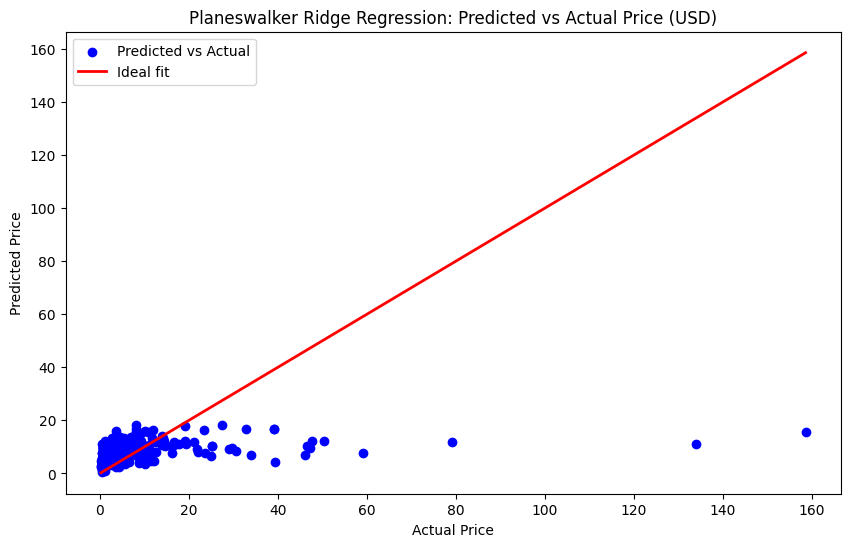

In [29]:
#plot actual versus predicted values on plot
pw_y_values_dict = {
    'planeswalk_y_test_raw': planeswalk_y_test_raw,
    'planeswalk_ridge_y_predict': planeswalk_ridge_y_predict
    }
pw_y_values = pd.DataFrame(
    pw_y_values_dict,
    columns=['planeswalk_y_test_raw', 'planeswalk_ridge_y_predict']
    )
pw_y_values_3std_max = (pw_y_values['planeswalk_y_test_raw'].std()*3)+ pw_y_values['planeswalk_y_test_raw'].mean()
pw_y_values_adj = pw_y_values[abs(pw_y_values['planeswalk_y_test_raw'])< pw_y_values_3std_max ]

planeswalk_pred_vs_actual_plt = pred_vs_actual(
    pw_y_values_adj['planeswalk_y_test_raw'],
    pw_y_values_adj['planeswalk_ridge_y_predict'],
    "Planeswalker")
planeswalk_pred_vs_actual_plt.show()

#### Coefficient Path Plot Function

In [30]:
#plot coefficient path plot from regression function
pw_r_line_plot.show()

# 5. Non-Creature Analysis

## 5a. Prep data (includes lemmatize, train test split, normalize)

#### Extract Non-Creature Data and Lemmatize the ability text

In [31]:
#extract non-creature data only and average prices for duplicate cards with exact features
non_creature_df = ridge_lasso_data_df[
    (ridge_lasso_data_df['isCreature'] == 0)& 
    (ridge_lasso_data_df['isPlaneswalker'] == 0)]
non_creature_df = aggregateDuplicates(non_creature_df)
print(len(non_creature_df))
non_creature_df.head(5)

6853


,uuid,cardName,availability,edhrecRank,edhrecSaltiness,isAlternative,isGameChanger,isPromo,isReprint,isReserved,...,finishes:_foil,finishes:_nonfoil,finishes:_signed,colorid:_B,colorid:_Colorless,colorid:_G,colorid:_R,colorid:_U,colorid:_W,price
0,000db0e0-047e-59e2-b7aa-265e656ea91c,Entangler,"mtgo, paper",10095.0,0.14,0,0,0,0,0,...,1,1,0,0,0,0,0,0,1,12.403636
1,000ed184-57ec-5b1e-a900-5d770a945999,Infinite Reflection,"mtgo, paper",16521.0,0.33,0,0,0,0,0,...,1,1,0,0,0,0,0,1,0,0.372000
2,002219b5-cd5e-561e-a752-aa2986e31ecd,Mechtitan Core,paper,4017.0,0.15,1,0,1,1,0,...,1,0,0,0,1,0,0,0,0,0.880000
3,004b3b84-db1d-5191-91d9-0b5844b8cf11,Peppersmoke,"mtgo, paper",15134.0,0.18,0,0,0,1,0,...,1,1,0,1,0,0,0,0,0,0.301111
4,004d21aa-69bc-508b-8a76-3fc5975ce6ab,Lance,paper,26974.0,0.20,0,0,0,1,0,...,0,1,0,0,0,0,0,0,1,1.003333


In [32]:
#lemmatize non-creature ability text
non_creature_df['text_lemmatized'] = non_creature_df['text'].apply(lemmatize_sentence)

#### Vectorize text using TF-IDF and Count Quantities

In [33]:
#Acquire counts for each word (not including stop words)
non_creature_min_ngram = 1
non_creature_max_ngram = 3
stop_words = 'english'

#TF IDF dataframe
non_creature_tfidf_vectorizer = TfidfVectorizer(
    max_features=17,
    stop_words=stop_words,
    ngram_range=(non_creature_min_ngram,non_creature_max_ngram)
    )
non_creature_tfidf_model = non_creature_tfidf_vectorizer.fit_transform(non_creature_df['text_lemmatized'])
non_creature_tfidf_ability_text = non_creature_tfidf_vectorizer.get_feature_names_out()
non_creature_tfidf_stop_words_vect = non_creature_tfidf_vectorizer.get_stop_words()
non_creature_tfidf_columns_text = ["contains_tfidf: "+ item for item in non_creature_tfidf_ability_text]
non_creature_tfidf_words_df = pd.DataFrame(
    non_creature_tfidf_model.toarray(),
    columns=non_creature_tfidf_columns_text
    )
non_creature_final_df = non_creature_df.join(non_creature_tfidf_words_df).fillna(0)

#Count Vectorizer dataframe
non_creature_count_vectorizer = CountVectorizer(
    max_features=11,
    stop_words=stop_words,
    ngram_range=(non_creature_min_ngram,non_creature_max_ngram)
    )
non_creature_count_model = non_creature_count_vectorizer.fit_transform(non_creature_df['text_lemmatized'])
non_creature_count_ability_text = non_creature_count_vectorizer.get_feature_names_out()
non_creature_count_stop_words_vect = non_creature_count_vectorizer.get_stop_words()
non_creature_count_columns_text = ["contains_count: "+ item for item in non_creature_count_ability_text]
non_creature_count_words_df = pd.DataFrame(
    non_creature_count_model.toarray(),
    columns=non_creature_count_columns_text
    )
non_creature_final_df = non_creature_final_df.join(non_creature_count_words_df).fillna(0)

#### Train Test Split MTGJSON Data

In [34]:
non_creature_X_columns = [
        'power', 
        'toughness', 
        'price', 
        'edhrecRank',
        'edhrecSaltiness', 
        'manaValue',
        'isReprint',
        'isAlternative',
        'isGameChanger',
        'isPromo',
        'isReserved',
        'isHuman', 
        'isElemental',
        'isDragon', 
        'isSpirit', 
        'isAngel', 
        'isElf',
        'isVampire', 
        'isZombie',
        'isBeast', 
        'isWizard',
        'isEldrazi',
        'isSoldier', 
        'isKnight', 
        'isCleric', 
        'isWarrior',
        'isRogue', 
        'isShaman', 
        'isDruid', 
        'isCreature',
        'isPlaneswalker',
        'isMTGO', 
        'isFlying',
        'isLegal',
        'isBanned',
        'rarity:_common',
        'rarity:_mythic',
        'rarity:_rare',
        'rarity:_special',
        'rarity:_uncommon',
        'finishes:_etched',
        'finishes:_foil',
        'finishes:_nonfoil',
        'finishes:_signed',
        'colorid:_B',
        'colorid:_Colorless',
        'colorid:_G',
        'colorid:_R',
        'colorid:_U',
        'colorid:_W'
        ] + non_creature_tfidf_columns_text + non_creature_count_columns_text
non_creature_y_column = "price"
non_creature_X_columns.remove(non_creature_y_column)

non_creature_X = non_creature_final_df[non_creature_X_columns]
non_creature_y = non_creature_final_df[non_creature_y_column]

#Split Data
non_creature_X_train_raw, non_creature_X_test_raw, non_creature_y_train_raw, non_creature_y_test_raw = train_test_split(
    non_creature_X,
    non_creature_y,
    random_state=random_state
    )

#Normalize data for non binary columns
non_creature_scaled_columns = [
        'power',
        'toughness',
        'edhrecRank',
        'edhrecSaltiness',
        'manaValue']
non_creature_X_train_norm= non_creature_X_train_raw.copy()
non_creature_X_test_norm = non_creature_X_test_raw.copy()
non_creature_train_features = non_creature_X_train_norm[non_creature_scaled_columns]
non_creature_test_features = non_creature_X_test_norm[non_creature_scaled_columns]

non_creature_scaler = StandardScaler().fit(non_creature_train_features.values)
non_creature_train_features = non_creature_scaler.transform(non_creature_train_features.values)
non_creature_test_features = non_creature_scaler.transform(non_creature_test_features.values)

non_creature_X_train_norm[non_creature_scaled_columns] = non_creature_train_features
non_creature_X_test_norm[non_creature_scaled_columns] = non_creature_test_features

## 5b. Create Model with Hyperparameter Tuning

### Parameters to tune

In [35]:
# Utilize same parameters as Creature Analysis

### Ridge Model

In [36]:
#Create Ridge Regression Model
non_creature_ridge_clf = Ridge()

#Fit model with TF-IDF
non_creature_X_train_norm_tfidf = non_creature_X_train_norm.copy().drop(columns=non_creature_count_columns_text)
non_creature_X_test_norm_tfidf = non_creature_X_test_norm.copy().drop(columns=non_creature_count_columns_text)
non_creature_ridge_clf_hyp = GridSearchCV(estimator=non_creature_ridge_clf, param_grid=parameters, cv=5)
non_creature_ridge_clf_hyp_tfidf = non_creature_ridge_clf_hyp.fit(non_creature_X_train_norm_tfidf, non_creature_y_train_raw)
non_creature_ridge_tfidf_score = non_creature_ridge_clf_hyp_tfidf.score(non_creature_X_test_norm_tfidf, non_creature_y_test_raw)
print("Ridge TF-IDF Score: ",non_creature_ridge_tfidf_score)

#Fit model with Count Quantities
non_creature_X_train_norm_count = non_creature_X_train_norm.copy().drop(columns=non_creature_tfidf_columns_text)
non_creature_X_test_norm_count =non_creature_X_test_norm.copy().drop(columns=non_creature_tfidf_columns_text)
non_creature_ridge_clf_hyp = GridSearchCV(estimator=non_creature_ridge_clf, param_grid=parameters, cv=5)
non_creature_ridge_clf_hyp_count = non_creature_ridge_clf_hyp.fit(non_creature_X_train_norm_count, non_creature_y_train_raw)
non_creature_ridge_count_score = non_creature_ridge_clf_hyp_count.score(non_creature_X_test_norm_count, non_creature_y_test_raw)
print("Ridge Count Score: ",non_creature_ridge_count_score)


#Identify best model
if non_creature_ridge_tfidf_score > non_creature_ridge_count_score:
    non_creature_X_train_norm_ridge = non_creature_X_train_norm.copy().drop(columns=non_creature_count_columns_text)
    non_creature_X_test_norm_ridge = non_creature_X_test_norm.copy().drop(columns=non_creature_count_columns_text)
    if non_creature_X_train_norm_ridge.columns.str.contains("contains_count: ").any():
        print("CHECK COLUMNS")
        print(non_creature_X_train_norm_ridge.columns[non_creature_X_train_norm_ridge.columns.str.contains("contains_count: ")].tolist())
    else:
        print("COLUMNS ARE GOOD")
        print("USE TDF-IDF SCORE FOR RIDGE MODEL")
else:
    non_creature_X_train_norm_ridge = non_creature_X_train_norm.copy().drop(columns=non_creature_tfidf_columns_text)
    non_creature_X_test_norm_ridge = non_creature_X_test_norm.copy().drop(columns=non_creature_tfidf_columns_text)
    if non_creature_X_train_norm_ridge.columns.str.contains("contains_tfidf: ", case=False).any():
        print("CHECK COLUMNS")
        print(non_creature_X_train_norm_ridge.columns[non_creature_X_train_norm_ridge.columns.str.contains("contains_tfidf: ")].tolist())
    else:
        print("COLUMNS ARE GOOD")
        print("USE COUNT QUANTITIES FOR LASSO MODEL")

non_creature_ridge_clf_hyp, non_creat_r_coeffs_df, non_creat_r_score_df, non_creat_r_line_plot = ridge_model_with_graph(
    non_creature_X_train_norm_ridge, 
    non_creature_y_train_raw,
    "Non-Creature",
    num_alphas=200)

non_creature_ridge_clf_hyp = non_creature_ridge_clf_hyp[-1]

Ridge TF-IDF Score:  0.0037308999403178333
Ridge Count Score:  0.0021304136805194718
COLUMNS ARE GOOD
USE TDF-IDF SCORE FOR RIDGE MODEL


## 5c. Acquire Parameters / Evaluate Metrics

In [37]:
#Gather Evaluation metrics for Ridge model from function
non_creature_ridge_y_predict = non_creature_ridge_clf_hyp.predict(non_creature_X_test_norm_ridge)
non_creature_ridge_mse = non_creat_r_score_df.iloc[0,3]
non_creature_ridge_mse_std_dev = non_creat_r_score_df.iloc[0,4]
non_creature_ridge_mae = non_creat_r_score_df.iloc[0,5]
non_creature_ridge_mae_std_dev =non_creat_r_score_df.iloc[0,6]
non_creature_ridge_best_score = non_creat_r_score_df.iloc[0,1]
non_creature_ridge_std_dev = non_creat_r_score_df.iloc[0,2]
non_creature_ridge_alpha_value = non_creat_r_score_df.iloc[0,0]

print("RIDGE MODEL for NON-CREATURES")
print(f"Best Regulation value (Lambda/Alpha Score): {non_creature_ridge_alpha_value}")
print(f"Best R-Square Score of Test Data (Mean[STD_DEV]): {non_creature_ridge_best_score} [{non_creature_ridge_std_dev}]")
print(f"Mean Square error (Mean[STD_DEV]): {non_creature_ridge_mse*-1} [{non_creature_ridge_mse_std_dev}]")
print(f"Mean Absolute error (Mean[STD_DEV]): {non_creature_ridge_mae*-1}  [{non_creature_ridge_mae_std_dev}]")
print("----------------------------------------")

RIDGE MODEL for NON-CREATURES
Best Regulation value (Lambda/Alpha Score): 4.500557675700507
Best R-Square Score of Test Data (Mean[STD_DEV]): 0.2227451219686996 [0.11013515869069795]
Mean Square error (Mean[STD_DEV]): 69132.68812479275 [41602.693476218185]
Mean Absolute error (Mean[STD_DEV]): 52.53257857177304  [6.587115262680013]
----------------------------------------


In [38]:
#Evaluate feature_importance for ridge Model
non_creature_ridge_feature_importance = pd.DataFrame(
    non_creat_r_coeffs_df[
        non_creat_r_coeffs_df['Model_Score'].isin([non_creature_ridge_best_score])
        ]
    )

non_creature_ridge_feature_importance['Abs_Val_Coefficients'] = abs(non_creature_ridge_feature_importance['Coefficients'])
non_creature_ridge_feature_importance.sort_values(
    'Abs_Val_Coefficients',
    ascending=False,
    inplace=True
    )
print("RIDGE MODEL")
print(non_creature_ridge_feature_importance.head(25))
print("----------------------------------------")

RIDGE MODEL
    Coefficients                             Features  Model_Reg_Lambda  \
106   839.545419                           isReserved          4.500558   
106   197.945676                              isLegal          4.500558   
106   104.675694                     finishes:_signed          4.500558   
106    74.478296                  contains_tfidf: add          4.500558   
106   -73.904828                 contains_tfidf: land          4.500558   
106   -59.820056            contains_tfidf: enchanted          4.500558   
106   -57.391936                         rarity:_rare          4.500558   
106   -54.978212                     finishes:_etched          4.500558   
106   -53.765894               contains_tfidf: enters          4.500558   
106   -53.576366  contains_tfidf: nenchanted creature          4.500558   
106   -53.180918                       rarity:_mythic          4.500558   
106   -52.944207                 contains_tfidf: card          4.500558   
106   -52.467

## 5d. Visualizations

#### Residual Plot

In [39]:
#plot residual plot based on results
non_creature_chart = residual_plot(
    non_creature_y_test_raw,
    non_creature_ridge_y_predict,
    "Residual Plot for MTG Non-Creature Cards"
    )
non_creature_chart.show()


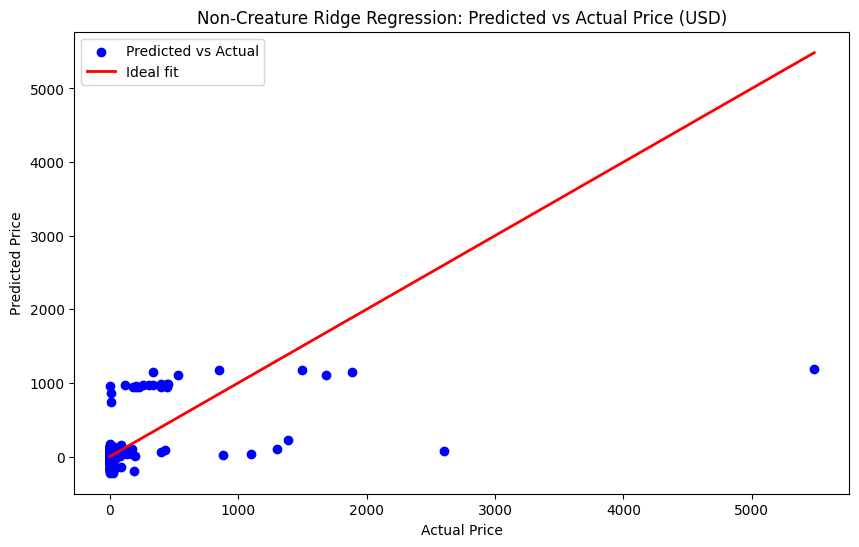

In [40]:
#plot actual versus predicted values on plot
nc_y_values_dict = {
    'non_creature_y_test_raw': non_creature_y_test_raw,
    'non_creature_ridge_y_predict': non_creature_ridge_y_predict
    }
nc_y_values = pd.DataFrame(
    nc_y_values_dict,
    columns=['non_creature_y_test_raw', 'non_creature_ridge_y_predict']
    )
nc_y_values_3std_max = (nc_y_values['non_creature_y_test_raw'].std()*3)+ nc_y_values['non_creature_y_test_raw'].mean()
nc_y_values_adj = nc_y_values[abs(nc_y_values['non_creature_y_test_raw'])< nc_y_values_3std_max ]

non_creat_pred_vs_actual_plt = pred_vs_actual(
    nc_y_values_adj['non_creature_y_test_raw'],
    nc_y_values_adj['non_creature_ridge_y_predict'],
    "Non-Creature"
    )
non_creat_pred_vs_actual_plt.show()

#### Coefficient Path Plot Function

In [41]:
#plot coefficient path plot from regression function
non_creat_r_line_plot.show()

## 5e. Failure Analysis

In [42]:
#Extract 'isReserved' features to given this feature extremely high
reserved_non_creature_X_train_norm_ridge = non_creature_X_train_norm_ridge.drop('isReserved', axis=1)
reserved_non_creature_X_test_norm_ridge = non_creature_X_test_norm_ridge.drop('isReserved', axis=1)

#Redo ridge regression for non-creatures without reserved field
reserved_non_creature_ridge_clf_hyp, reserved_non_creat_r_coeffs_df, reserved_non_creat_r_score_df, reserved_non_creat_r_line_plot = ridge_model_with_graph(
    reserved_non_creature_X_train_norm_ridge, 
    non_creature_y_train_raw,
    "Non-Reserved, Non-Creature",
    num_alphas=200)

reserved_non_creature_ridge_clf_hyp = reserved_non_creature_ridge_clf_hyp[-1]

reserved_non_creat_r_line_plot.show()

In [43]:
#Compare Evaluation metrics with and without Reserverd feature in model
print("RIDGE MODEL for NON-CREATURES")
print(f"Best Regulation value (Lambda/Alpha Score): {non_creature_ridge_alpha_value}")
print(f"Best R-Square Score of Test Data (Mean[STD_DEV]): {non_creature_ridge_best_score} [{non_creature_ridge_std_dev}]")
print(f"Mean Square error (Mean[STD_DEV]): {non_creature_ridge_mse*-1} [{non_creature_ridge_mse_std_dev}]")
print(f"Mean Absolute error (Mean[STD_DEV]): {non_creature_ridge_mae*-1}  [{non_creature_ridge_mae_std_dev}]")
print("----------------------------------------")

reserved_non_creature_ridge_y_predict = reserved_non_creature_ridge_clf_hyp.predict(
    reserved_non_creature_X_test_norm_ridge)
reserved_non_creature_ridge_mse = reserved_non_creat_r_score_df.iloc[0,3]
reserved_non_creature_ridge_mse_std_dev = reserved_non_creat_r_score_df.iloc[0,4]
reserved_non_creature_ridge_mae = reserved_non_creat_r_score_df.iloc[0,5]
reserved_non_creature_ridge_mae_std_dev =reserved_non_creat_r_score_df.iloc[0,6]
reserved_non_creature_ridge_best_score = reserved_non_creat_r_score_df.iloc[0,1]
reserved_non_creature_ridge_std_dev = reserved_non_creat_r_score_df.iloc[0,2]
reserved_non_creature_ridge_alpha_value = reserved_non_creat_r_score_df.iloc[0,0]

print("RIDGE MODEL for NON-RESERVED, NON-CREATURES")
print(f"Best Regulation value (Lambda/Alpha Score): {reserved_non_creature_ridge_alpha_value}")
print(f"Best R-Square Score of Test Data (Mean[STD_DEV]): {reserved_non_creature_ridge_best_score} [{reserved_non_creature_ridge_std_dev}]")
print(f"Mean Square error (Mean[STD_DEV]): {reserved_non_creature_ridge_mse*-1} [{reserved_non_creature_ridge_mse_std_dev}]")
print(f"Mean Absolute error (Mean[STD_DEV]): {reserved_non_creature_ridge_mae*-1}  [{reserved_non_creature_ridge_mae_std_dev}]")
print("----------------------------------------")

#Identify which features are the highest out of all of the features without 'isReserved'
reserved_non_creature_ridge_feature_importance = pd.DataFrame(
    reserved_non_creat_r_coeffs_df[
        reserved_non_creat_r_coeffs_df['Model_Score'].isin([reserved_non_creature_ridge_best_score])
        ]
    )

reserved_non_creature_ridge_feature_importance['Abs_Val_Coefficients'] = abs(reserved_non_creature_ridge_feature_importance['Coefficients'])
reserved_non_creature_ridge_feature_importance.sort_values(
    'Abs_Val_Coefficients',
    ascending=False,
    inplace=True
    )
print("RIDGE MODEL")
print(reserved_non_creature_ridge_feature_importance.head(25))
print("----------------------------------------")

RIDGE MODEL for NON-CREATURES
Best Regulation value (Lambda/Alpha Score): 4.500557675700507
Best R-Square Score of Test Data (Mean[STD_DEV]): 0.2227451219686996 [0.11013515869069795]
Mean Square error (Mean[STD_DEV]): 69132.68812479275 [41602.693476218185]
Mean Absolute error (Mean[STD_DEV]): 52.53257857177304  [6.587115262680013]
----------------------------------------
RIDGE MODEL for NON-RESERVED, NON-CREATURES
Best Regulation value (Lambda/Alpha Score): 4.500557675700507
Best R-Square Score of Test Data (Mean[STD_DEV]): 0.11013949470344939 [0.05077886682645936]
Mean Square error (Mean[STD_DEV]): 76875.69914775176 [40685.97560538279]
Mean Absolute error (Mean[STD_DEV]): 71.43821819799776  [6.195972269860118]
----------------------------------------
RIDGE MODEL
    Coefficients                             Features  Model_Reg_Lambda  \
106   214.029397                  contains_tfidf: add          4.500558   
106   -161.50833               contains_tfidf: enters          4.500558   
1

In [44]:
#Residual plot without with estimations from model without isReserved feature
reserved_non_creature_chart = residual_plot(
    non_creature_y_test_raw,
    reserved_non_creature_ridge_y_predict,
    "Residual Plot for MTG Non-Reserved, Non-Creature Cards"
    )
reserved_non_creature_chart.show()

#### SHAP Analysis

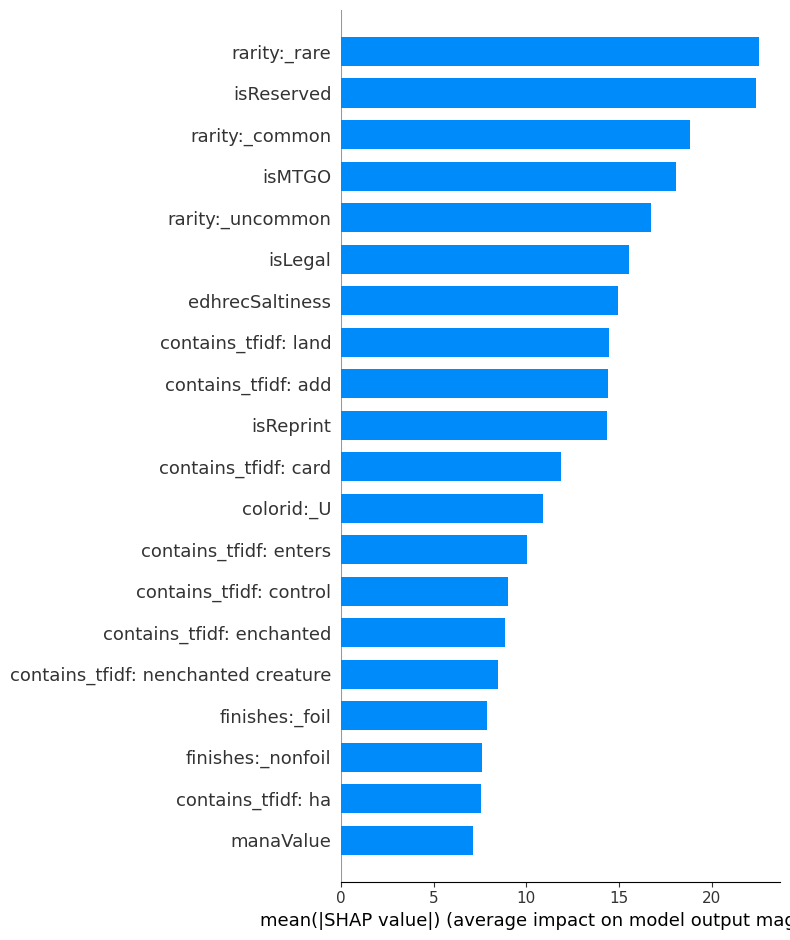

In [45]:
#Run SHAP analysis on Non-creature Training data to understand feature importance to model
explainer = shap.LinearExplainer(
    non_creature_ridge_clf_hyp,
    non_creature_X_test_norm_ridge.astype(float)
    )
shap_values = explainer(non_creature_X_test_norm_ridge.astype(float))

#Display average impact of shap values to baseline and compare to most features
shap.summary_plot(
    shap_values.values,
    non_creature_X_test_norm_ridge.astype(float),
    feature_names = non_creature_X_test_norm_ridge.columns,
    plot_type='bar'
    )

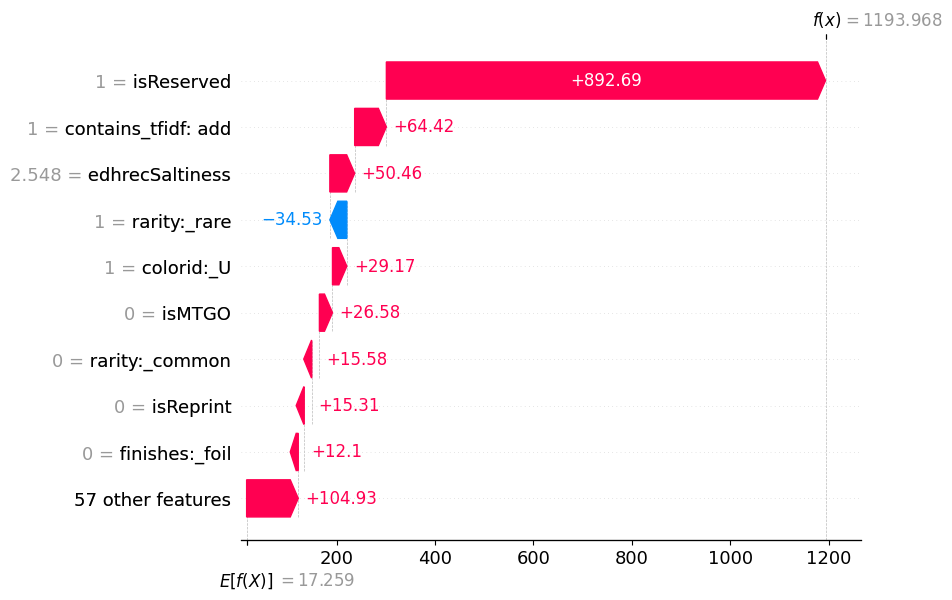

In [46]:
#show impact of feature to baseline prediction for "Tropical Island" card

#ID for tropical island
tropical_island_id = np.where(non_creature_y_test_raw == 5485.35)[0][0]

#Impact to ba locally
shap.plots.waterfall(shap_values[tropical_island_id])